# DATA266 Lab 1 Part 2 - Member A

## Yelp Polarity Sentiment Classification

This notebook trains three sentiment models from scratch:

1. Baseline: learned embedding plus mean pooling.
2. Experiment 1: learned embedding plus 1D CNN.
3. Experiment 2: learned embedding plus bidirectional GRU.

No pretrained embeddings or pretrained language models are used.

Use free Colab only for a smoke test. Run the full experiment in the GPU lab.


In [3]:
!pip -q install datasets scikit-learn scipy statsmodels nltk tqdm matplotlib pandas


In [4]:
# Drive works in Colab. For a local GPU-lab Jupyter session, change PROJECT_DIR.
from pathlib import Path
import json, os, re, time, random, math, csv
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = Path('/content/drive/MyDrive/Sem3/DATA266/Lab1/Part2')
except ImportError:
    PROJECT_DIR = Path.cwd() / 'Part2'

DATA_DIR = PROJECT_DIR / 'data'
CHECKPOINT_DIR = PROJECT_DIR / 'checkpoints'
OUTPUT_DIR = PROJECT_DIR / 'outputs'
LOG_DIR = PROJECT_DIR / 'logs'
CONFIG_DIR = PROJECT_DIR / 'configs'
NOTEBOOK_DIR = PROJECT_DIR / 'notebooks'

for folder in [DATA_DIR, CHECKPOINT_DIR, OUTPUT_DIR, LOG_DIR, CONFIG_DIR, NOTEBOOK_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print('Project folder:', PROJECT_DIR)


Mounted at /content/drive
Project folder: /content/drive/MyDrive/Sem3/DATA266/Lab1/Part2


In [5]:
# Member A configuration.
CONFIG = {
    'member': 'Anushka',
    'seed': 3963,
    'dataset': 'fancyzhx/yelp_polarity',
    'max_vocab': 30_000,
    'max_length': 200,
    'embedding_dim': 128,
    'dropout': 0.30,
    'batch_size': 64,
    'recurrent_batch_size': 64,
    'epochs': 10,
    'learning_rate': 5e-4,
    'baseline_learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'cnn_channels': 128,
    'cnn_kernels': [3, 4, 5],
    'bigru_hidden_size': 128,
    'num_workers': 2,
    'bootstrap_repetitions': 1000
}

RUN_FULL_TRAINING = True
SMOKE_TRAIN_SAMPLES = 10_000
SMOKE_VALIDATION_SAMPLES = 2_000
SMOKE_TEST_SAMPLES = 2_000
SMOKE_EPOCHS = 1
SMOKE_BOOTSTRAP_REPETITIONS = 100

(CONFIG_DIR / 'config.json').write_text(json.dumps(CONFIG, indent=2))
print(json.dumps(CONFIG, indent=2))


{
  "member": "Anushka",
  "seed": 3963,
  "dataset": "fancyzhx/yelp_polarity",
  "max_vocab": 30000,
  "max_length": 200,
  "embedding_dim": 128,
  "dropout": 0.3,
  "batch_size": 64,
  "recurrent_batch_size": 64,
  "epochs": 10,
  "learning_rate": 0.0005,
  "baseline_learning_rate": 0.001,
  "weight_decay": 0.0001,
  "cnn_channels": 128,
  "cnn_kernels": [
    3,
    4,
    5
  ],
  "bigru_hidden_size": 128,
  "num_workers": 2,
  "bootstrap_repetitions": 1000
}


In [6]:
# Reproducibility and device.
SEED = CONFIG['seed']
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


## 2.1 Data Preprocessing

This section:
- Loads Yelp Polarity.
- Checks class balance and review lengths.
- Cleans text by lowercasing, removing punctuation and special characters, and removing stopwords.
- Tokenizes the cleaned text.
- Learns the vocabulary from the training split only.
- Creates embeddings from scratch later inside each model.


In [7]:
# Load Yelp Polarity and create a member-specific stratified validation split.
dataset = load_dataset(CONFIG['dataset'])
train_all = dataset['train'].shuffle(seed=SEED)
split = train_all.train_test_split(
    test_size=0.10,
    seed=SEED,
    stratify_by_column='label'
)
train_raw = split['train']
validation_raw = split['test']
test_raw = dataset['test']

if not RUN_FULL_TRAINING:
    train_raw = train_raw.select(range(min(SMOKE_TRAIN_SAMPLES, len(train_raw))))
    validation_raw = validation_raw.select(range(min(SMOKE_VALIDATION_SAMPLES, len(validation_raw))))
    test_raw = test_raw.select(range(min(SMOKE_TEST_SAMPLES, len(test_raw))))

print('Train:', len(train_raw))
print('Validation:', len(validation_raw))
print('Test:', len(test_raw))
print('Label names:', dataset['train'].features['label'].names)


README.md:   0%|          | 0.00/8.93k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  256MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 17.7MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/38000 [00:00<?, ? examples/s]

Train: 504000
Validation: 56000
Test: 38000
Label names: ['1', '2']


In [8]:
# Text cleaning and required data analysis.
STOPWORDS = {
    'a','an','and','are','as','at','be','but','by','for','from','in','into',
    'is','it','of','on','or','that','the','their','there','this','to','was',
    'were','with','you','your','i','we','they','he','she'
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    tokens = [token for token in text.split() if token not in STOPWORDS]
    return ' '.join(tokens)

def prepare_split(split):
    raw_texts = list(split['text'])
    labels = np.asarray(split['label'], dtype=np.int64)
    cleaned = [clean_text(text) for text in tqdm(raw_texts, desc='Cleaning')]
    word_lengths = np.asarray([len(text.split()) for text in cleaned], dtype=np.int64)
    return raw_texts, cleaned, labels, word_lengths

train_original, train_texts, train_labels, train_lengths = prepare_split(train_raw)
validation_original, validation_texts, validation_labels, validation_lengths = prepare_split(validation_raw)
test_original, test_texts, test_labels, test_lengths = prepare_split(test_raw)

analysis_df = pd.DataFrame({
    'split': (['train'] * len(train_labels)) + (['validation'] * len(validation_labels)) + (['test'] * len(test_labels)),
    'label': np.concatenate([train_labels, validation_labels, test_labels]),
    'word_length': np.concatenate([train_lengths, validation_lengths, test_lengths])
})
analysis_df.to_csv(OUTPUT_DIR / 'data_analysis.csv', index=False)

print('Class counts:')
print(analysis_df.groupby(['split', 'label']).size())
print('Length summary:')
print(analysis_df.groupby('split')['word_length'].describe())


Cleaning:   0%|          | 0/504000 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/56000 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/38000 [00:00<?, ?it/s]

Class counts:
split       label
test        0         19000
            1         19000
train       0        252000
            1        252000
validation  0         28000
            1         28000
dtype: int64
Length summary:
               count       mean        std  min   25%   50%    75%    max
split                                                                    
test         38000.0  90.725474  82.889603  1.0  35.0  66.0  119.0  700.0
train       504000.0  91.063036  83.873993  0.0  35.0  66.0  119.0  848.0
validation   56000.0  91.261804  84.507980  0.0  35.0  66.0  119.0  805.0


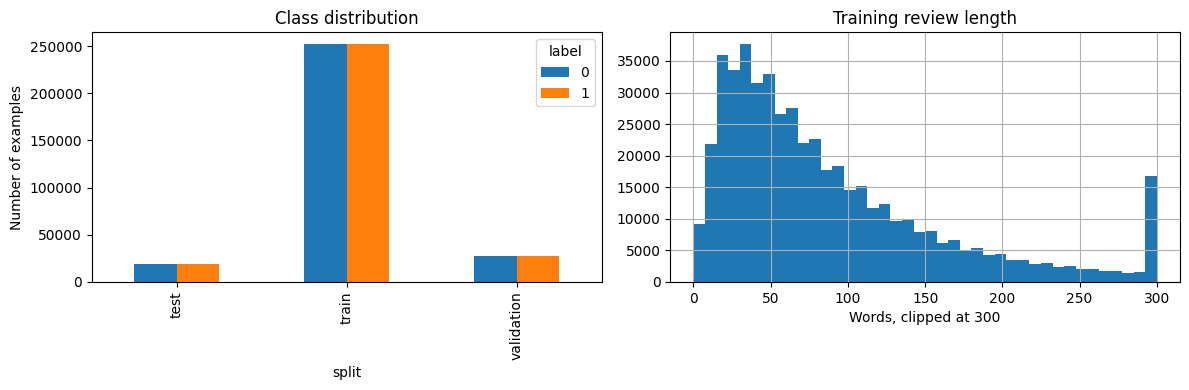

In [9]:
# Plot class distribution and review-length distribution.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
analysis_df.groupby(['split', 'label']).size().unstack(fill_value=0).plot(kind='bar', ax=axes[0])
axes[0].set_title('Class distribution')
axes[0].set_ylabel('Number of examples')
analysis_df[analysis_df['split'] == 'train']['word_length'].clip(upper=300).hist(bins=40, ax=axes[1])
axes[1].set_title('Training review length')
axes[1].set_xlabel('Words, clipped at 300')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'data_distribution.png', dpi=160)
plt.show()


In [10]:
## ================ Learned vocabulary and tokenization ================

from collections import Counter

counter = Counter()
for text in tqdm(train_texts, desc='Building vocabulary'):
    counter.update(text.split())

itos = ['<pad>', '<unk>'] + [word for word, _ in counter.most_common(CONFIG['max_vocab'] - 2)]
stoi = {word: index for index, word in enumerate(itos)}
PAD_ID = stoi['<pad>']
UNK_ID = stoi['<unk>']

def encode_text(text):
    ids = [stoi.get(token, UNK_ID) for token in text.split()]
    ids = ids[:CONFIG['max_length']]
    ids += [PAD_ID] * (CONFIG['max_length'] - len(ids))
    return np.asarray(ids, dtype=np.int64)

train_encoded = np.stack([encode_text(text) for text in tqdm(train_texts, desc='Encoding train')])
validation_encoded = np.stack([encode_text(text) for text in tqdm(validation_texts, desc='Encoding validation')])
test_encoded = np.stack([encode_text(text) for text in tqdm(test_texts, desc='Encoding test')])

(CONFIG_DIR / 'vocabulary.json').write_text(json.dumps({
    'itos': itos,
    'vocabulary_size': len(itos),
    'max_length': CONFIG['max_length']
}, indent=2))

print('Vocabulary size:', len(itos))
print('Encoded train shape:', train_encoded.shape)


Building vocabulary:   0%|          | 0/504000 [00:00<?, ?it/s]

Encoding train:   0%|          | 0/504000 [00:00<?, ?it/s]

Encoding validation:   0%|          | 0/56000 [00:00<?, ?it/s]

Encoding test:   0%|          | 0/38000 [00:00<?, ?it/s]

Vocabulary size: 30000
Encoded train shape: (504000, 200)


## 2.2 Model Training and Evaluation

Each model uses a learned embedding layer. No pretrained embedding or language model is used.

Member A models:

- Baseline: mean pooling.
- Experiment 1: CNN with kernel sizes 3, 4, and 5.
- Experiment 2: one-layer bidirectional GRU.

All three models use the same data split, vocabulary, maximum sequence length, and evaluation protocol.


In [11]:
class ReviewDataset(Dataset):
    def __init__(self, encoded, labels):
        self.encoded = torch.tensor(encoded, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.encoded[index], self.labels[index]

train_dataset = ReviewDataset(train_encoded, train_labels)
validation_dataset = ReviewDataset(validation_encoded, validation_labels)
test_dataset = ReviewDataset(test_encoded, test_labels)

def make_loader(dataset, batch_size, shuffle):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=CONFIG['num_workers'],
        pin_memory=torch.cuda.is_available()
    )

train_loader = make_loader(train_dataset, CONFIG['batch_size'], True)
validation_loader = make_loader(validation_dataset, CONFIG['batch_size'], False)
test_loader = make_loader(test_dataset, CONFIG['batch_size'], False)
print('Batches:', len(train_loader), len(validation_loader), len(test_loader))


Batches: 7875 875 594


In [12]:
# Member A model 1: baseline learned embedding plus mean pooling.
class MeanPoolingClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, dropout, pad_id):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_id)
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2)
        )
        self.pad_id = pad_id

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        mask = (input_ids != self.pad_id).unsqueeze(-1)
        masked = embedded * mask
        pooled = masked.sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return self.classifier(pooled)


In [13]:
# Member A model 2: learned embedding plus parallel 1D CNN.
class CNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, channels, kernels, dropout, pad_id):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_id)
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, channels, kernel_size=k)
            for k in kernels
        ])
        self.classifier = nn.Sequential(
            nn.Linear(channels * len(kernels), 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2)
        )

    def forward(self, input_ids):
        x = self.embedding(input_ids).transpose(1, 2)
        features = [torch.max(torch.relu(conv(x)), dim=2).values for conv in self.convs]
        combined = torch.cat(features, dim=1)
        return self.classifier(combined)


In [14]:
# Member A model 3: learned embedding plus one-layer bidirectional GRU.
class BiGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, dropout, pad_id):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_id)
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2)
        )

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        _, hidden = self.gru(embedded)
        final_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.classifier(final_hidden)


In [15]:
MODEL_BUILDERS = {
    'baseline': lambda: MeanPoolingClassifier(
        len(itos), CONFIG['embedding_dim'], CONFIG['dropout'], PAD_ID
    ),
    'cnn': lambda: CNNClassifier(
        len(itos), CONFIG['embedding_dim'], CONFIG['cnn_channels'],
        CONFIG['cnn_kernels'], CONFIG['dropout'], PAD_ID
    ),
    'bigru': lambda: BiGRUClassifier(
        len(itos), CONFIG['embedding_dim'], CONFIG['bigru_hidden_size'],
        CONFIG['dropout'], PAD_ID
    )
}

for name, builder in MODEL_BUILDERS.items():
    model_check = builder()
    print(name, f'{sum(p.numel() for p in model_check.parameters() if p.requires_grad):,} parameters')


baseline 3,848,386 parameters
cnn 4,086,530 parameters
bigru 4,071,298 parameters


### Training

Each model is trained independently using cross-entropy loss. The full run uses eight epochs. The smoke test uses one epoch and a smaller subset so that the code can be checked before GPU training.


In [16]:
def multiclass_ece(probabilities, labels, bins=10):
    confidences = probabilities.max(axis=1)
    predictions = probabilities.argmax(axis=1)
    accuracies = predictions == labels
    edges = np.linspace(0.0, 1.0, bins + 1)
    ece = 0.0
    for lower, upper in zip(edges[:-1], edges[1:]):
        selected = (confidences > lower) & (confidences <= upper)
        if selected.any():
            ece += selected.mean() * abs(
                accuracies[selected].mean() - confidences[selected].mean()
            )
    return float(ece)

def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    criterion = nn.CrossEntropyLoss()
    total_loss, total_correct, total_examples = 0.0, 0, 0
    probabilities_all, labels_all = [], []
    start = time.time()

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        if training:
            optimizer.zero_grad(set_to_none=True)

        logits = model(inputs)
        loss = criterion(logits, labels)

        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        probabilities = torch.softmax(logits, dim=1)
        total_loss += float(loss.detach()) * labels.size(0)
        total_correct += int((logits.argmax(dim=1) == labels).sum())
        total_examples += labels.size(0)
        probabilities_all.append(probabilities.detach().cpu().numpy())
        labels_all.append(labels.detach().cpu().numpy())

    elapsed = time.time() - start
    probs = np.concatenate(probabilities_all)
    labels = np.concatenate(labels_all)
    return {
        'loss': total_loss / total_examples,
        'accuracy': total_correct / total_examples,
        'probabilities': probs,
        'labels': labels,
        'examples_per_second': total_examples / max(elapsed, 1e-9),
        'time_seconds': elapsed
    }

def train_one_model(name, builder):
    model = builder().to(device)
    learning_rate = CONFIG['baseline_learning_rate'] if name == 'baseline' else CONFIG['learning_rate']
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=CONFIG['weight_decay']
    )
    epochs = CONFIG['epochs'] if RUN_FULL_TRAINING else SMOKE_EPOCHS
    history = {'train_loss': [], 'validation_loss': [], 'train_accuracy': [], 'validation_accuracy': []}
    log_path = LOG_DIR / f'{name}_training_log.txt'
    start_total = time.time()

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    with log_path.open('w') as log:
        for epoch in range(epochs):
            train_result = run_epoch(model, train_loader, optimizer)
            validation_result = run_epoch(model, validation_loader)
            history['train_loss'].append(train_result['loss'])
            history['validation_loss'].append(validation_result['loss'])
            history['train_accuracy'].append(train_result['accuracy'])
            history['validation_accuracy'].append(validation_result['accuracy'])

            line = (
                f'Epoch {epoch+1}: train_loss={train_result["loss"]:.6f}, '
                f'val_loss={validation_result["loss"]:.6f}, '
                f'train_accuracy={train_result["accuracy"]:.6f}, '
                f'val_accuracy={validation_result["accuracy"]:.6f}\n'
            )
            print(name, line.strip())
            log.write(line)
            log.flush()

    total_time = time.time() - start_total
    peak_memory = torch.cuda.max_memory_allocated() / (1024**2) if torch.cuda.is_available() else 0.0
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'model_name': name,
        'config': CONFIG,
        'vocabulary': itos,
        'history': history
    }
    torch.save(checkpoint, CHECKPOINT_DIR / f'{name}.pt')

    return model, history, total_time, peak_memory

trained = {}
for name, builder in MODEL_BUILDERS.items():
    print(f'\nTraining {name}...')
    trained[name] = train_one_model(name, builder)



Training baseline...
baseline Epoch 1: train_loss=0.212774, val_loss=0.183796, train_accuracy=0.916218, val_accuracy=0.929768
baseline Epoch 2: train_loss=0.167040, val_loss=0.179212, train_accuracy=0.936960, val_accuracy=0.931304
baseline Epoch 3: train_loss=0.156808, val_loss=0.180089, train_accuracy=0.940796, val_accuracy=0.931054
baseline Epoch 4: train_loss=0.150608, val_loss=0.179215, train_accuracy=0.942829, val_accuracy=0.931304
baseline Epoch 5: train_loss=0.145911, val_loss=0.181302, train_accuracy=0.944772, val_accuracy=0.931482
baseline Epoch 6: train_loss=0.141619, val_loss=0.184833, train_accuracy=0.946107, val_accuracy=0.931482
baseline Epoch 7: train_loss=0.137990, val_loss=0.189939, train_accuracy=0.947510, val_accuracy=0.931518
baseline Epoch 8: train_loss=0.133948, val_loss=0.190168, train_accuracy=0.948942, val_accuracy=0.930482
baseline Epoch 9: train_loss=0.129761, val_loss=0.191380, train_accuracy=0.950440, val_accuracy=0.931071
baseline Epoch 10: train_loss=0.1

## 2.3 Comparative Analysis and Required Metrics

The following section computes the required metrics for every model and performs paired comparisons on the same test examples.


In [17]:
# Metric helpers.
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    brier_score_loss, f1_score
)
from scipy.stats import chi2
from statsmodels.stats.contingency_tables import mcnemar

def bootstrap_ci(y_true, probabilities, repetitions):
    rng = np.random.default_rng(SEED)
    predictions = probabilities.argmax(axis=1)
    values = {'accuracy': [], 'macro_f1': [], 'mcc': []}
    for _ in range(repetitions):
        indexes = rng.integers(0, len(y_true), size=len(y_true))
        yt = y_true[indexes]
        yp = predictions[indexes]
        values['accuracy'].append(accuracy_score(yt, yp))
        values['macro_f1'].append(f1_score(yt, yp, average='macro', zero_division=0))
        values['mcc'].append(matthews_corrcoef(yt, yp))
    return {
        metric: [float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))]
        for metric, vals in values.items()
    }

def calculate_metrics(name, model):
    test_result = run_epoch(model, test_loader)
    y_true = test_result['labels']
    probabilities = test_result['probabilities']
    predictions = probabilities.argmax(axis=1)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, predictions, average=None, zero_division=0
    )
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_true, predictions, average='macro', zero_division=0
    )
    p_micro, r_micro, f_micro, _ = precision_recall_fscore_support(
        y_true, predictions, average='micro', zero_division=0
    )
    p_weight, r_weight, f_weight, _ = precision_recall_fscore_support(
        y_true, predictions, average='weighted', zero_division=0
    )

    positive_probabilities = probabilities[:, 1]
    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_true, predictions),
        'precision_macro': p_macro,
        'recall_macro': r_macro,
        'f1_macro': f_macro,
        'precision_micro': p_micro,
        'recall_micro': r_micro,
        'f1_micro': f_micro,
        'precision_weighted': p_weight,
        'recall_weighted': r_weight,
        'f1_weighted': f_weight,
        'roc_auc': roc_auc_score(y_true, positive_probabilities),
        'pr_auc': average_precision_score(y_true, positive_probabilities),
        'mcc': matthews_corrcoef(y_true, predictions),
        'brier_score': brier_score_loss(y_true, positive_probabilities),
        'ece': multiclass_ece(probabilities, y_true),
        'parameter_count': sum(p.numel() for p in model.parameters() if p.requires_grad),
        'test_examples_per_second': test_result['examples_per_second'],
        'test_time_seconds': test_result['time_seconds'],
        'training_time_seconds': trained[name][2],
        'peak_memory_mb': trained[name][3]
    }
    ci = bootstrap_ci(
        y_true,
        probabilities,
        CONFIG['bootstrap_repetitions'] if RUN_FULL_TRAINING else SMOKE_BOOTSTRAP_REPETITIONS
    )
    metrics['accuracy_ci_low'], metrics['accuracy_ci_high'] = ci['accuracy']
    metrics['macro_f1_ci_low'], metrics['macro_f1_ci_high'] = ci['macro_f1']
    metrics['mcc_ci_low'], metrics['mcc_ci_high'] = ci['mcc']
    return metrics, test_result, predictions

all_metrics = []
test_predictions = {}
test_results = {}
for name, (model, history, total_time, peak_memory) in trained.items():
    metrics, result, predictions = calculate_metrics(name, model)
    all_metrics.append(metrics)
    test_results[name] = result
    test_predictions[name] = predictions

metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv(OUTPUT_DIR / 'metrics_report.csv', index=False)
display(metrics_df)


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_micro,recall_micro,f1_micro,precision_weighted,recall_weighted,...,test_examples_per_second,test_time_seconds,training_time_seconds,peak_memory_mb,accuracy_ci_low,accuracy_ci_high,macro_f1_ci_low,macro_f1_ci_high,mcc_ci_low,mcc_ci_high
0,baseline,0.934974,0.935106,0.934974,0.934969,0.934974,0.934974,0.934974,0.935106,0.934974,...,21419.422675,1.774091,465.618098,90.755371,0.932710,0.937421,0.932687,0.937418,0.865486,0.874978
1,cnn,0.942553,0.942556,0.942553,0.942553,0.942553,0.942553,0.942553,0.942556,0.942553,...,16051.287242,2.367411,888.576757,198.645020,0.940421,0.944948,0.940420,0.944947,0.880843,0.889895
2,bigru,0.947605,0.947727,0.947605,0.947602,0.947605,0.947605,0.947605,0.947727,0.947605,...,13872.935861,2.739146,843.363205,355.362793,0.945210,0.949711,0.945200,0.949705,0.890538,0.899529


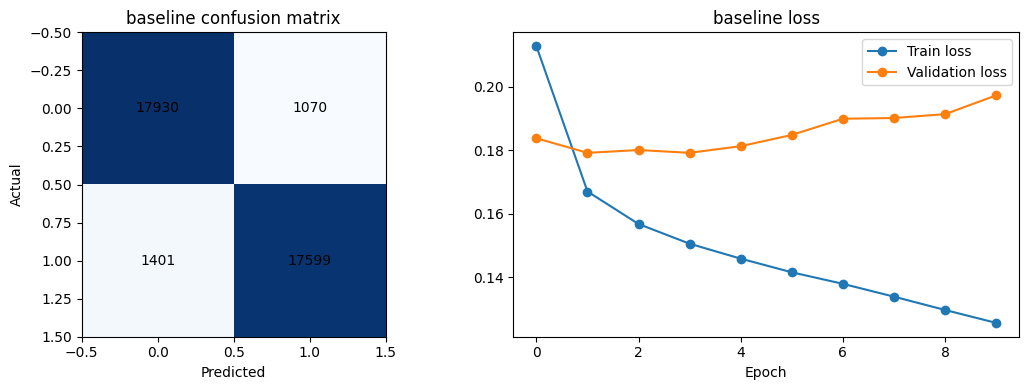

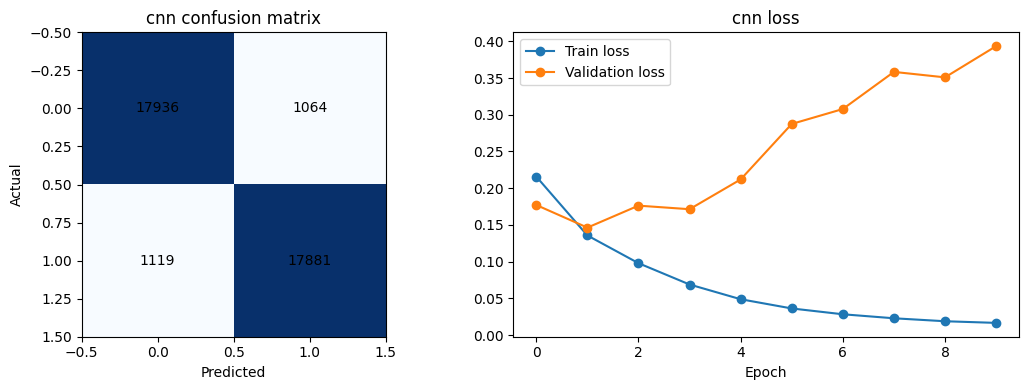

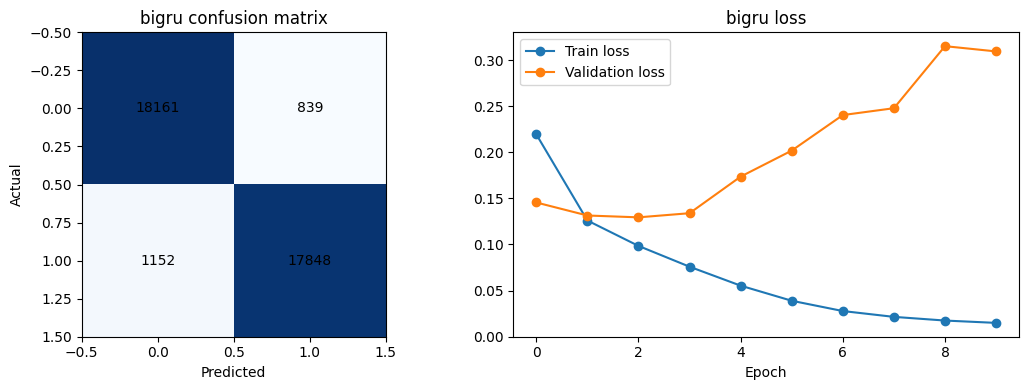

In [18]:
# Confusion matrices and training curves.
for name, (model, history, total_time, peak_memory) in trained.items():
    cm = confusion_matrix(test_results[name]['labels'], test_predictions[name])
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(cm, cmap='Blues')
    axes[0].set_title(f'{name} confusion matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    for r in range(2):
        for c in range(2):
            axes[0].text(c, r, cm[r, c], ha='center', va='center')
    axes[1].plot(history['train_loss'], marker='o', label='Train loss')
    axes[1].plot(history['validation_loss'], marker='o', label='Validation loss')
    axes[1].set_title(f'{name} loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{name}_evaluation.png', dpi=160)
    plt.show()


In [19]:
# Paired McNemar tests: baseline versus each experimental model.
y_true = test_results['baseline']['labels']
baseline_correct = test_predictions['baseline'] == y_true
mcnemar_rows = []

for experimental_name in ['cnn', 'bigru']:
    experimental_correct = test_predictions[experimental_name] == y_true
    both_correct = int(np.sum(baseline_correct & experimental_correct))
    baseline_only = int(np.sum(baseline_correct & ~experimental_correct))
    experimental_only = int(np.sum(~baseline_correct & experimental_correct))
    both_wrong = int(np.sum(~baseline_correct & ~experimental_correct))
    contingency = [[both_correct, baseline_only], [experimental_only, both_wrong]]
    result = mcnemar(contingency, exact=False, correction=True)
    mcnemar_rows.append({
        'comparison': f'baseline_vs_{experimental_name}',
        'baseline_only_correct': baseline_only,
        'experimental_only_correct': experimental_only,
        'chi2_statistic': float(result.statistic),
        'p_value': float(result.pvalue)
    })

mcnemar_df = pd.DataFrame(mcnemar_rows)
mcnemar_df.to_csv(OUTPUT_DIR / 'mcnemar_tests.csv', index=False)
display(mcnemar_df)


,comparison,baseline_only_correct,experimental_only_correct,chi2_statistic,p_value
0,baseline_vs_cnn,1030,1318,35.080494,3.163539e-09
1,baseline_vs_bigru,860,1340,104.291364,1.746486e-24


In [20]:
# Robustness slices by review length.
slice_rows = []
for name in MODEL_BUILDERS:
    predictions = test_predictions[name]
    for slice_name, mask in {
        'very_short_0_20_words': test_lengths <= 20,
        'short_21_50_words': (test_lengths > 20) & (test_lengths <= 50),
        'medium_51_200_words': (test_lengths > 50) & (test_lengths <= 200),
        'long_over_200_words': test_lengths > 200
    }.items():
        if mask.sum() == 0:
            continue
        yt = test_labels[mask]
        yp = predictions[mask]
        slice_rows.append({
            'model': name,
            'slice': slice_name,
            'count': int(mask.sum()),
            'macro_f1': f1_score(yt, yp, average='macro', zero_division=0),
            'error_rate': float(np.mean(yt != yp))
        })

slice_df = pd.DataFrame(slice_rows)
slice_df.to_csv(OUTPUT_DIR / 'slice_robustness.csv', index=False)
display(slice_df)


,model,slice,count,macro_f1,error_rate
0,baseline,very_short_0_20_words,4337,0.923778,0.071247
1,baseline,short_21_50_words,10344,0.942305,0.057038
2,baseline,medium_51_200_words,19875,0.936031,0.063648
3,baseline,long_over_200_words,3444,0.899998,0.089141
4,cnn,very_short_0_20_words,4337,0.930853,0.064561
5,cnn,short_21_50_words,10344,0.945776,0.053461
6,cnn,medium_51_200_words,19875,0.946795,0.052981
7,cnn,long_over_200_words,3444,0.903787,0.086237
8,bigru,very_short_0_20_words,4337,0.936682,0.059027
9,bigru,short_21_50_words,10344,0.952447,0.046984


## Required 20 Error Review

Review errors from your strongest model after the full GPU run:

- 5 confident false positives.
- 5 confident false negatives.
- 5 near-threshold errors.
- 5 slice-specific failures.

For every error, record the review text, true label, predicted label, confidence, error type, observation, and one testable fix.


In [21]:
# Select exactly 20 errors for the required manual review:
# 5 confident false positives
# 5 confident false negatives
# 5 near-threshold errors
# 5 slice-specific failures

best_model_name = metrics_df.sort_values("f1_macro", ascending=False).iloc[0]["model"]

best_result = test_results[best_model_name]
best_probabilities = best_result["probabilities"]
best_predictions = test_predictions[best_model_name]
best_true = best_result["labels"]

error_rows = []

for index, (raw, cleaned, true_label, prediction, probabilities, length) in enumerate(
    zip(
        test_original,
        test_texts,
        best_true,
        best_predictions,
        best_probabilities,
        test_lengths
    )
):
    if true_label == prediction:
        continue

    confidence = float(probabilities[prediction])

    if true_label == 0 and prediction == 1:
        initial_type = "false_positive"
    else:
        initial_type = "false_negative"

    if length <= 20:
        slice_name = "very_short_0_20_words"
    elif length <= 50:
        slice_name = "short_21_50_words"
    elif length <= 200:
        slice_name = "medium_51_200_words"
    else:
        slice_name = "long_over_200_words"

    error_rows.append({
        "index": index,
        "raw_text": raw,
        "cleaned_text": cleaned,
        "true_label": int(true_label),
        "predicted_label": int(prediction),
        "confidence": confidence,
        "distance_from_threshold": abs(confidence - 0.5),
        "word_length": int(length),
        "slice": slice_name,
        "initial_error_type": initial_type
    })

all_errors = pd.DataFrame(error_rows)

selected = []
used_indices = set()

def add_rows(dataframe, count, review_group):
    available = dataframe[~dataframe["index"].isin(used_indices)].head(count)

    for _, row in available.iterrows():
        record = row.to_dict()
        record["review_group"] = review_group
        record["reviewed_error_type"] = ""
        record["observation"] = ""
        record["testable_fix"] = ""
        selected.append(record)
        used_indices.add(record["index"])

# 1. Five confident false positives
false_positives = all_errors[
    all_errors["initial_error_type"] == "false_positive"
].sort_values("confidence", ascending=False)

add_rows(false_positives, 5, "confident_false_positive")

# 2. Five confident false negatives
false_negatives = all_errors[
    all_errors["initial_error_type"] == "false_negative"
].sort_values("confidence", ascending=False)

add_rows(false_negatives, 5, "confident_false_negative")

# 3. Five near-threshold errors
near_threshold = all_errors.sort_values(
    "distance_from_threshold", ascending=True
)

add_rows(near_threshold, 5, "near_threshold_error")

# 4. Five slice-specific errors
# Long reviews are the weakest observed slice, so prioritize them.
slice_specific = all_errors[
    all_errors["slice"] == "long_over_200_words"
].sort_values("confidence", ascending=False)

# If fewer than five long-review errors remain, use very short reviews.
if len(slice_specific) < 5:
    fallback = all_errors[
        all_errors["slice"] == "very_short_0_20_words"
    ].sort_values("confidence", ascending=False)

    slice_specific = pd.concat(
        [slice_specific, fallback],
        ignore_index=True
    )

# Final fallback guarantees five rows if a slice is too small.
if len(slice_specific) < 5:
    slice_specific = all_errors.sort_values(
        "word_length", ascending=False
    )

add_rows(slice_specific, 5, "slice_specific_failure")

# Save exactly 20 rows
error_review_df = pd.DataFrame(selected)

# Remove helper column from final submission file
error_review_df = error_review_df[
    [
        "index",
        "raw_text",
        "cleaned_text",
        "true_label",
        "predicted_label",
        "confidence",
        "word_length",
        "slice",
        "initial_error_type",
        "review_group",
        "reviewed_error_type",
        "observation",
        "testable_fix"
    ]
]

error_review_df.to_csv(
    OUTPUT_DIR / "error_review_20.csv",
    index=False
)

print("Selected rows:", len(error_review_df))
print(error_review_df["review_group"].value_counts())
print("Saved:", OUTPUT_DIR / "error_review_20.csv")

Selected rows: 20
review_group
confident_false_positive    5
confident_false_negative    5
near_threshold_error        5
slice_specific_failure      5
Name: count, dtype: int64
Saved: /content/drive/MyDrive/Sem3/DATA266/Lab1/Part2/outputs/error_review_20.csv


## Final Output Checklist

Before submission, confirm that the executed notebook and these files exist:

- notebooks/Part2_MemberA_Yelp_Sentiment.ipynb
- checkpoints/baseline.pt
- checkpoints/cnn.pt
- checkpoints/bigru.pt
- outputs/data_analysis.csv
- outputs/data_distribution.png
- outputs/metrics_report.csv
- outputs/mcnemar_tests.csv
- outputs/slice_robustness.csv
- outputs/error_review_20_template.csv
- outputs/baseline_evaluation.png
- outputs/cnn_evaluation.png
- outputs/bigru_evaluation.png
- logs/baseline_training_log.txt
- logs/cnn_training_log.txt
- logs/bigru_training_log.txt
- configs/config.json
- configs/vocabulary.json
- results.md
- failure_analysis.md


In [22]:
# Create the required written-report templates.
(PROJECT_DIR / 'results.md').write_text('''# Part 2 Results

## Data preprocessing
Describe the data cleaning, tokenization, vocabulary, sequence length, class balance, and split.

## Model architectures
Explain the baseline, CNN, and BiGRU models and why the embedding choices were made.

## Metrics
Summarize outputs/metrics_report.csv, outputs/mcnemar_tests.csv, and outputs/slice_robustness.csv.

## Error analysis
Summarize the manually reviewed 20 errors from outputs/error_review_20_template.csv.

## Hardware
Record the exact GPU used, training time, examples per second, and peak memory.

## Limitations and future work
Explain weaknesses and one or two testable improvements.
''', encoding='utf-8')

(PROJECT_DIR / 'failure_analysis.md').write_text('''# Part 2 Error Analysis

Complete the 20 manually reviewed examples in outputs/error_review_20_template.csv.

Use the required groups:
- 5 confident false positives
- 5 confident false negatives
- 5 near-threshold errors
- 5 slice-specific failures

For every example, assign an error type, write an observation, and propose one testable fix.
''', encoding='utf-8')
print('Created results.md and failure_analysis.md templates.')


Created results.md and failure_analysis.md templates.
